<a href="https://colab.research.google.com/github/julesz827/quantprojects/blob/main/dice_market_maker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Skew: 0.05, Avg PNL: 475.25799999999987, Inventory Risk: 2.2
     0.0      500.0       24.2
   0.005      497.7        7.5
    0.01      495.3        5.5
    0.02      490.2        3.5
    0.03      485.2        3.3
    0.05      475.3        2.2


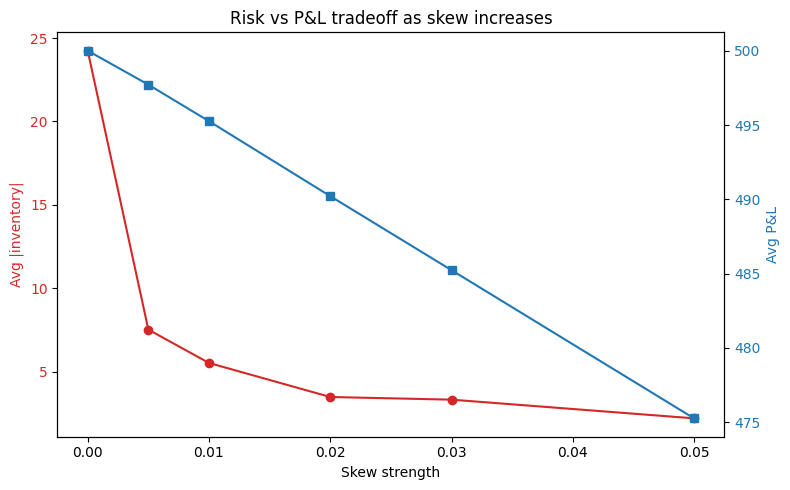

In [39]:
import random

def roll_two_dice():
  return random.randint(1, 6) + random.randint(1, 6)

def true_expected_value(trials=100_000):
  total = 0
  for _ in range(trials):
    total += roll_two_dice()
  return total / trials

class MarketMaker:
  def __init__(self, fair_value, spread, skew_strength=0.0):
    self.fair_value = fair_value
    self.spread = spread
    self.skew_strength = skew_strength
    self.inventory = 0
    self.cash = 0

  def quote(self):
    half = self.spread / 2
    center = self.fair_value - self.inventory * self.skew_strength
    bid = center - half
    ask = center + half
    return (bid, ask)

  def trade(self, side, price):
    if side == "sell":
      self.inventory -= 1
      self.cash += price
    else:
      self.inventory += 1
      self.cash -= price

  def pnl(self, settle_value):
     return self.cash + self.inventory * settle_value

def run_simulation(mm, rounds=1000):
  for _ in range(rounds):
      bid, ask = mm.quote()
      midpoint = (bid + ask) / 2
      buy_probability = 0.5 + (mm.fair_value - midpoint) * 0.5
      buy_probability = max(0.0, min(1.0, buy_probability))
      if random.random() < buy_probability:
        mm.trade("sell", ask)
      else:
        mm.trade("buy", bid)
  return mm.pnl(mm.fair_value)

import matplotlib.pyplot as plt

skew_values = [0.0, 0.005, 0.01, 0.02, 0.03, 0.05]
avg_pnls = []
inventory_risks = []

for skew in skew_values:
    pnls = []
    final_inventories = []
    for trial in range(50):
        mm = MarketMaker(7, spread=1, skew_strength=skew)
        pnl = run_simulation(mm, rounds=1000)
        pnls.append(pnl)
        final_inventories.append(abs(mm.inventory))

    avg_pnls.append(sum(pnls) / len(pnls))
    inventory_risks.append(sum(final_inventories) / len(final_inventories))

print(f"Skew: {skew}, Avg PNL: {avg_pnls[-1]}, Inventory Risk: {inventory_risks[-1]}")
for i in range(len(skew_values)):
  print(f"{skew_values[i]:>8} {avg_pnls[i]:>10.1f} {inventory_risks[i]:>10.1f}")

import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(skew_values, inventory_risks, marker='o', color='tab:red', label='Avg inventory risk')
ax1.set_xlabel('Skew strength')
ax1.set_ylabel('Avg |inventory|', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(skew_values, avg_pnls, marker='s', color='tab:blue', label='Avg P&L')
ax2.set_ylabel('Avg P&L', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Risk vs P&L tradeoff as skew increases')
fig.tight_layout()
plt.show()
